# This is to build baseline per hour
Builds baseline population patterns per hour (0h, 8h, 16h) for each quadkey (2.5km grid cell), calculating normal population counts and typical fluctuations  


Baseline and Normal Change
- Removed Special time snapshot
- All remaining snapshot columns (including previously labeled “crisis”) are treated as normal baseline counts per `quadkey`.
- Columns are grouped by hour (0, 8, 16) to calculate separate baselines for each daily timeslot.
- For each quadkey and hour, **baseline** = mean count, **normal_change_ratio** = typical relative fluctuation, **normal_change_number** = typical absolute fluctuation.
- Result: three DataFrames (`0h`, `8h`, `16h`) with   
`quadkey | baseline | normal_change_ratio | normal_change_number`

# No conf score, but might get one? 

# Data source: Data for Good at Meta

Facebook 人口地图: https://dataforgood.facebook.com/dfg/tools/facebook-population-maps#resources  
人口流动地图: https://dataforgood.facebook.com/dfg/tools/movement-maps 

2.5 possibaly using Microsoft's Bing Maps Tile System (QuadTree) 

Using Digital Footprint Data to Measure and Monitor Human Mobility Tutorial(from Liverpool):     
https://fcorowe.github.io/dfd4mobility/spatial-patterns.html  
Carmen's code: https://github.com/carmen-cabrera/vlc-floods-mobility/tree/main/code  

Twitetr about Nairobi percolation: https://x.com/MidoCollins/status/1466389583285952514

In [24]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from collections import defaultdict

# Visualisation
import folium
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from folium.plugins import HeatMap

# Geospatial processing
import mercantile
import contextily as cx
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import Point, box

# === Functions ===
def quadkey_to_geometry(quadkey):
    tile = mercantile.quadkey_to_tile(quadkey)
    bbox = mercantile.bounds(tile)  # returns west, south, east, north
    return box(bbox.west, bbox.south, bbox.east, bbox.north)

BASE_DIR = Path('/Users/wenlanzhang/Downloads/PhD_UCL/Data/Meta/')
OUT_DIR = Path('/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste_flood/Meta/')


This should record code to downsample the FB data from 2.5km to 500m. 
- Nairobi  
- Coordinates of grid, 2.5km  
- Time: 2023-06-08_0000 to 2023-07-05_1600, at 8 and 16 clock

Full data: `PDC_24_0424_0514`, `PDC_23_0608_0705`  
Nairobi data: `PDC_Nairobi_24_0424_0514`, `PDC_Nairobi_23_0608_0705`  
AOI data: `PDC_aoi_24_0424_0514`, `PDC_aoi_23_0608_0705`

Might 不准的地方：16: midium low and May10 

# Create Baseline VS Crisis Dataset (Done)

In [6]:
df_PDC_24 = pd.read_csv(BASE_DIR/'Population During Crisis/Processed/PDC_aoi_24_0424_0514.csv')

df_PDC_24 = df_PDC_24[['quadkey', 'date_time', 'n_crisis']]
# Ensure datetime
df_PDC_24["date_time"] = pd.to_datetime(df_PDC_24["date_time"])
df_PDC_24["quadkey"] = df_PDC_24["quadkey"].astype(str)

df_PDC_24

,quadkey,date_time,n_crisis
0,30011010223203,2024-04-24 00:00:00,494.954219
1,30011010220311,2024-04-24 00:00:00,44.019190
2,30011010222110,2024-04-24 00:00:00,530.702329
3,30011010230212,2024-04-24 00:00:00,758.872417
4,30011010222310,2024-04-24 00:00:00,555.107783
...,...,...,...
15192,30011010220033,2024-05-14 16:00:00,86.012348
15193,30011010232020,2024-05-14 16:00:00,1104.546067
15194,30011010230202,2024-05-14 16:00:00,670.751081
15195,30011010230022,2024-05-14 16:00:00,164.663904


## Create baseline (shifted 7 days later)

In [8]:
df_shifted = df_PDC_24.copy()
df_shifted["date_time"] = df_shifted["date_time"] - pd.Timedelta(days=7)
df_shifted = df_shifted.rename(columns={"n_crisis": "n_baseline"})
# df_shifted

df_merged = pd.merge(df_PDC_24, df_shifted, on=["quadkey", "date_time"], how="left")
df_merged

,quadkey,date_time,n_crisis,n_baseline
0,30011010223203,2024-04-24 00:00:00,494.954219,452.568417
1,30011010220311,2024-04-24 00:00:00,44.019190,70.564917
2,30011010222110,2024-04-24 00:00:00,530.702329,762.721513
3,30011010230212,2024-04-24 00:00:00,758.872417,652.911256
4,30011010222310,2024-04-24 00:00:00,555.107783,453.540045
...,...,...,...,...
15192,30011010220033,2024-05-14 16:00:00,86.012348,NaN
15193,30011010232020,2024-05-14 16:00:00,1104.546067,NaN
15194,30011010230202,2024-05-14 16:00:00,670.751081,NaN
15195,30011010230022,2024-05-14 16:00:00,164.663904,NaN


## Only keep the event week

In [9]:
# Define datetime bounds with full precision
start = pd.to_datetime("2024-04-29 00:00:00")
end   = pd.to_datetime("2024-05-03 23:59:59")

mask = (df_merged["date_time"] >= start) & (df_merged["date_time"] <= end)
df_filtered = df_merged.loc[mask]

# Drop rows where both crisis and baseline are NaN
df_filtered = df_filtered.dropna(subset=["n_crisis", "n_baseline"], how="all")
df_filtered

,quadkey,date_time,n_crisis,n_baseline
3624,30011010221211,2024-04-29 00:00:00,279.039638,301.829523
3625,30011010223123,2024-04-29 00:00:00,3604.888126,3586.118607
3626,30011010232201,2024-04-29 00:00:00,NaN,313.023629
3627,30011010232101,2024-04-29 00:00:00,36.753105,NaN
3628,30011010223203,2024-04-29 00:00:00,515.518439,500.398290
...,...,...,...,...
7234,30011010221333,2024-05-03 16:00:00,2226.734730,2327.358311
7235,30011010221230,2024-05-03 16:00:00,418.601915,426.860889
7236,30011012000111,2024-05-03 16:00:00,235.388004,221.419773
7237,30011010232222,2024-05-03 16:00:00,332.987411,321.610726


## Convert to GeoDataFrame 

In [11]:
df_filtered["geometry"] = df_filtered["quadkey"].apply(quadkey_to_geometry)
FB_gdf = gpd.GeoDataFrame(df_filtered, geometry="geometry", crs="EPSG:4326")

FB_gdf.head()

,quadkey,date_time,n_crisis,n_baseline,geometry
3624,30011010221211,2024-04-29,279.039638,301.829523,"POLYGON ((36.82617 -1.16447, 36.82617 -1.1425,..."
3625,30011010223123,2024-04-29,3604.888126,3586.118607,"POLYGON ((36.87012 -1.31824, 36.87012 -1.29628..."
3626,30011010232201,2024-04-29,NaN,313.023629,"POLYGON ((36.95801 -1.34021, 36.95801 -1.31824..."
3627,30011010232101,2024-04-29,36.753105,NaN,"POLYGON ((37.0459 -1.25234, 37.0459 -1.23037, ..."
3628,30011010223203,2024-04-29,515.518439,500.398290,"POLYGON ((36.78223 -1.36218, 36.78223 -1.34021..."


## Export (32737)

In [14]:
FB_gdf = FB_gdf.to_crs("EPSG:32737")

path = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste_flood/Meta/FB_32737.gpkg"
FB_gdf.to_file(
    path,
    layer="population_change",
    driver="GPKG"
)
FB_gdf.head()

,quadkey,date_time,n_crisis,n_baseline,geometry
3624,30011010221211,2024-04-29,279.039638,301.829523,"POLYGON ((258098.592 9871197.54, 258096.736 98..."
3625,30011010223123,2024-04-29,3604.888126,3586.118607,"POLYGON ((263004.777 9854192.901, 263002.715 9..."
3626,30011010232201,2024-04-29,NaN,313.023629,"POLYGON ((272790.762 9851771.55, 272788.753 98..."
3627,30011010232101,2024-04-29,36.753105,NaN,"POLYGON ((282566.613 9861497.334, 282564.817 9..."
3628,30011010223203,2024-04-29,515.518439,500.398290,"POLYGON ((253224.641 9849324.721, 253222.422 9..."


# 下面好像没有用

# Wide format 

In [15]:
# path = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Clean/FB_n_3857.gpkg"
path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste_flood/Meta/FB_32737.gpkg'
# Read the specific layer
FB_gdf = gpd.read_file(path, layer="population_change")

print(FB_gdf.crs) 
FB_gdf

EPSG:32737


,quadkey,date_time,n_crisis,n_baseline,geometry
0,30011010221211,2024-04-29 00:00:00,279.039638,301.829523,"POLYGON ((258098.592 9871197.54, 258096.736 98..."
1,30011010223123,2024-04-29 00:00:00,3604.888126,3586.118607,"POLYGON ((263004.777 9854192.901, 263002.715 9..."
2,30011010232201,2024-04-29 00:00:00,NaN,313.023629,"POLYGON ((272790.762 9851771.55, 272788.753 98..."
3,30011010232101,2024-04-29 00:00:00,36.753105,NaN,"POLYGON ((282566.613 9861497.334, 282564.817 9..."
4,30011010223203,2024-04-29 00:00:00,515.518439,500.398290,"POLYGON ((253224.641 9849324.721, 253222.422 9..."
...,...,...,...,...,...
3495,30011010221333,2024-05-03 16:00:00,2226.734730,2327.358311,"POLYGON ((267888.961 9863915.72, 267887.078 98..."
3496,30011010221230,2024-05-03 16:00:00,418.601915,426.860889,"POLYGON ((255656.157 9866335.797, 255654.21 98..."
3497,30011012000111,2024-05-03 16:00:00,235.388004,221.419773,"POLYGON ((248339.252 9842030.663, 248336.878 9..."
3498,30011010232222,2024-05-03 16:00:00,332.987411,321.610726,"POLYGON ((270351.136 9844480.879, 270349.004 9..."


In [16]:
# Make sure date_time is datetime
FB_gdf['date_time'] = pd.to_datetime(FB_gdf['date_time'])

# Keep geometry separately to avoid duplication issues during pivot
geom = FB_gdf[['quadkey', 'geometry']].drop_duplicates(subset='quadkey')

# Pivot the data (long → wide)
fb_wide = (
    FB_gdf.drop(columns='geometry')
      .melt(id_vars=['quadkey', 'date_time'], 
            value_vars=['n_crisis', 'n_baseline'], 
            var_name='type', value_name='value')
      .assign(date_str=lambda d: d['date_time'].dt.strftime('%Y%m%d_%H%M'))
      .assign(col_name=lambda d: d['date_str'] + '_' + d['type'])
      .pivot(index='quadkey', columns='col_name', values='value')
      .reset_index()
)

# Merge geometry back
fb_wide = geom.merge(fb_wide, on='quadkey', how='right')

# Convert back to GeoDataFrame
fb_wide = gpd.GeoDataFrame(fb_wide, geometry='geometry', crs=FB_gdf.crs)

fb_wide.head()

,quadkey,geometry,20240429_0000_n_baseline,20240429_0000_n_crisis,20240429_0800_n_baseline,20240429_0800_n_crisis,20240429_1600_n_baseline,20240429_1600_n_crisis,20240430_0000_n_baseline,20240430_0000_n_crisis,...,20240502_0800_n_baseline,20240502_0800_n_crisis,20240502_1600_n_baseline,20240502_1600_n_crisis,20240503_0000_n_baseline,20240503_0000_n_crisis,20240503_0800_n_baseline,20240503_0800_n_crisis,20240503_1600_n_baseline,20240503_1600_n_crisis
0,30011010220033,"POLYGON ((238525.201 9873612.043, 238523.232 9...",126.593911,131.123511,114.665084,113.864063,72.972119,76.053538,123.273029,123.669832,...,106.454819,51.020857,74.534241,71.426788,126.117043,126.683337,105.730457,112.267757,67.758792,72.251675
1,30011010220210,"POLYGON ((236080.615 9871179.781, 236078.589 9...",36.668483,42.504930,37.294715,37.460781,24.904347,24.169276,40.535910,39.065031,...,34.990058,14.919045,23.365839,23.778877,44.115310,39.445634,35.650655,35.781904,21.937546,25.245141
2,30011010220211,"POLYGON ((238527.209 9871181.831, 238525.201 9...",117.157703,132.644358,111.260031,113.499546,74.101380,79.882559,114.914930,119.844024,...,100.093385,47.674714,72.889603,75.122056,121.444527,124.391953,106.952816,111.401965,67.779145,79.450080
3,30011010220212,"POLYGON ((236082.68 9868749.55, 236080.615 987...",30.204601,29.742974,31.525832,31.647936,19.689871,20.691453,27.486561,31.283406,...,30.889566,14.752194,21.159159,18.976103,33.992742,30.547338,31.721993,32.151338,16.751630,24.655830
4,30011010220213,"POLYGON ((238529.254 9868751.638, 238527.209 9...",74.726596,78.426679,82.606788,81.685521,53.585034,52.411525,72.334542,77.960888,...,80.347464,32.818313,61.136114,51.421719,98.265555,81.040155,83.558133,84.244086,52.112867,58.362148


In [20]:
fb_wide.columns

Index(['quadkey', 'geometry', '20240429_0000_n_baseline',
       '20240429_0000_n_crisis', '20240429_0800_n_baseline',
       '20240429_0800_n_crisis', '20240429_1600_n_baseline',
       '20240429_1600_n_crisis', '20240430_0000_n_baseline',
       '20240430_0000_n_crisis', '20240430_0800_n_baseline',
       '20240430_0800_n_crisis', '20240430_1600_n_baseline',
       '20240430_1600_n_crisis', '20240501_0000_n_baseline',
       '20240501_0000_n_crisis', '20240501_0800_n_baseline',
       '20240501_0800_n_crisis', '20240501_1600_n_baseline',
       '20240501_1600_n_crisis', '20240502_0000_n_baseline',
       '20240502_0000_n_crisis', '20240502_0800_n_baseline',
       '20240502_0800_n_crisis', '20240502_1600_n_baseline',
       '20240502_1600_n_crisis', '20240503_0000_n_baseline',
       '20240503_0000_n_crisis', '20240503_0800_n_baseline',
       '20240503_0800_n_crisis', '20240503_1600_n_baseline',
       '20240503_1600_n_crisis'],
      dtype='object')

In [18]:
fb_wide.to_file(
    '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste_flood/Meta/FB_32737_wide.gpkg',
    layer="population_change", driver="GPKG")

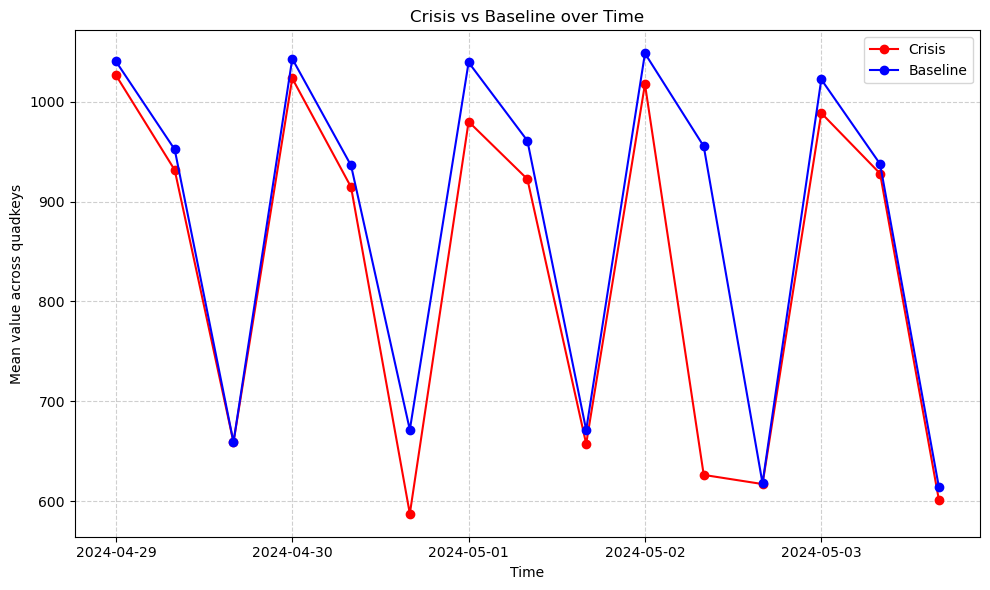

In [17]:
# --- Step 1: Copy your wide df (without geometry)
df = fb_wide.drop(columns='geometry')

# --- Step 2: Separate crisis and baseline columns
crisis_cols = [c for c in df.columns if c.endswith('_n_crisis')]
baseline_cols = [c for c in df.columns if c.endswith('_n_baseline')]

# --- Step 3: Extract datetime from column names
def extract_time(col):
    # Example col = '20240429_0000_n_crisis'
    date_part = col.split('_n_')[0]
    return pd.to_datetime(date_part, format='%Y%m%d_%H%M')

crisis_times = [extract_time(c) for c in crisis_cols]
baseline_times = [extract_time(c) for c in baseline_cols]

# --- Step 4: Compute mean value across all quadkeys for each time
crisis_series = df[crisis_cols].mean(axis=0)
baseline_series = df[baseline_cols].mean(axis=0)

# Create a tidy DataFrame for plotting
plot_df = pd.DataFrame({
    'time': crisis_times,
    'crisis': crisis_series.values,
    'baseline': baseline_series.values
}).sort_values('time')

# --- Step 5: Plot
plt.figure(figsize=(10,6))
plt.plot(plot_df['time'], plot_df['crisis'], label='Crisis', color='red', marker='o')
plt.plot(plot_df['time'], plot_df['baseline'], label='Baseline', color='blue', marker='o')
plt.xlabel('Time')
plt.ylabel('Mean value across quadkeys')
plt.title('Crisis vs Baseline over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [5]:
# Remove between 0430 - 0502

# # Make a copy
# FB_Baseline = fb_wide.copy()

# # Identify all crisis columns
# crisis_cols = [c for c in FB_Baseline.columns if c.endswith('_n_crisis')]

# # Function to extract datetime from column names like '20240430_0000_n_crisis'
# def extract_datetime(col):
#     try:
#         return pd.to_datetime(col.split('_n_crisis')[0], format='%Y%m%d_%H%M')
#     except Exception:
#         return pd.NaT

# # Map each crisis column to its datetime
# col_dates = {col: extract_datetime(col) for col in crisis_cols}

# # Define your cutoff times
# start = pd.Timestamp('2024-04-30 00:00')
# end   = pd.Timestamp('2024-05-02 16:00')

# # Identify which crisis columns fall within the unwanted range
# cols_to_drop = [col for col, dt in col_dates.items() if dt >= start and dt <= end]

# print(f"Removing {len(cols_to_drop)} crisis columns between {start} and {end}")

# # Drop those columns
# FB_Baseline = FB_Baseline.drop(columns=cols_to_drop)
# FB_Baseline

In [9]:
# Make a copy
FB_Baseline = fb_wide.copy()

# Identify all crisis columns
crisis_cols = [c for c in FB_Baseline.columns if c.endswith('_n_crisis')]

# Function to extract datetime from column names like '20240430_0000_n_crisis'
def extract_datetime(col):
    try:
        return pd.to_datetime(col.split('_n_crisis')[0], format='%Y%m%d_%H%M')
    except Exception:
        return pd.NaT

# Map each crisis column to its datetime
col_dates = {col: extract_datetime(col) for col in crisis_cols}

# List the exact timestamps you want to remove
snapshots_to_remove = [
    pd.Timestamp('2024-04-30 16:00'),
    pd.Timestamp('2024-05-01 00:00'),
    pd.Timestamp('2024-05-01 08:00'),
    pd.Timestamp('2024-05-02 08:00')
]

# Identify which crisis columns match the specified snapshots
cols_to_drop = [col for col, dt in col_dates.items() if dt in snapshots_to_remove]

print(f"Removing {len(cols_to_drop)} specified crisis columns")

# Drop those columns
FB_Baseline = FB_Baseline.drop(columns=cols_to_drop)
FB_Baseline.head()

Removing 4 specified crisis columns


,quadkey,geometry,20240429_0000_n_baseline,20240429_0000_n_crisis,20240429_0800_n_baseline,20240429_0800_n_crisis,20240429_1600_n_baseline,20240429_1600_n_crisis,20240430_0000_n_baseline,20240430_0000_n_crisis,...,20240502_0000_n_crisis,20240502_0800_n_baseline,20240502_1600_n_baseline,20240502_1600_n_crisis,20240503_0000_n_baseline,20240503_0000_n_crisis,20240503_0800_n_baseline,20240503_0800_n_crisis,20240503_1600_n_baseline,20240503_1600_n_crisis
0,30011010220033,"POLYGON ((238525.201 9873612.043, 238523.232 9...",126.593911,131.123511,114.665084,113.864063,72.972119,76.053538,123.273029,123.669832,...,123.235756,106.454819,74.534241,71.426788,126.117043,126.683337,105.730457,112.267757,67.758792,72.251675
1,30011010220210,"POLYGON ((236080.615 9871179.781, 236078.589 9...",36.668483,42.504930,37.294715,37.460781,24.904347,24.169276,40.535910,39.065031,...,40.496454,34.990058,23.365839,23.778877,44.115310,39.445634,35.650655,35.781904,21.937546,25.245141
2,30011010220211,"POLYGON ((238527.209 9871181.831, 238525.201 9...",117.157703,132.644358,111.260031,113.499546,74.101380,79.882559,114.914930,119.844024,...,122.486385,100.093385,72.889603,75.122056,121.444527,124.391953,106.952816,111.401965,67.779145,79.450080
3,30011010220212,"POLYGON ((236082.68 9868749.55, 236080.615 987...",30.204601,29.742974,31.525832,31.647936,19.689871,20.691453,27.486561,31.283406,...,29.782505,30.889566,21.159159,18.976103,33.992742,30.547338,31.721993,32.151338,16.751630,24.655830
4,30011010220213,"POLYGON ((238529.254 9868751.638, 238527.209 9...",74.726596,78.426679,82.606788,81.685521,53.585034,52.411525,72.334542,77.960888,...,77.196725,80.347464,61.136114,51.421719,98.265555,81.040155,83.558133,84.244086,52.112867,58.362148


# Build baseline

In [10]:
# Keep only the quadkey + all numeric snapshot columns
snapshot_cols = [c for c in FB_Baseline.columns if c not in ['quadkey', 'geometry']]
snapshot_cols

['20240429_0000_n_baseline',
 '20240429_0000_n_crisis',
 '20240429_0800_n_baseline',
 '20240429_0800_n_crisis',
 '20240429_1600_n_baseline',
 '20240429_1600_n_crisis',
 '20240430_0000_n_baseline',
 '20240430_0000_n_crisis',
 '20240430_0800_n_baseline',
 '20240430_0800_n_crisis',
 '20240430_1600_n_baseline',
 '20240501_0000_n_baseline',
 '20240501_0800_n_baseline',
 '20240501_1600_n_baseline',
 '20240501_1600_n_crisis',
 '20240502_0000_n_baseline',
 '20240502_0000_n_crisis',
 '20240502_0800_n_baseline',
 '20240502_1600_n_baseline',
 '20240502_1600_n_crisis',
 '20240503_0000_n_baseline',
 '20240503_0000_n_crisis',
 '20240503_0800_n_baseline',
 '20240503_0800_n_crisis',
 '20240503_1600_n_baseline',
 '20240503_1600_n_crisis']

In [11]:
def extract_hour(col):
    # remove suffixes like "_n_baseline" or "_n_crisis"
    col_base = col.rsplit('_n_', 1)[0]
    dt = pd.to_datetime(col_base, format='%Y%m%d_%H%M')
    return dt.hour

col_hours = {col: extract_hour(col) for col in snapshot_cols}
col_hours

{'20240429_0000_n_baseline': 0,
 '20240429_0000_n_crisis': 0,
 '20240429_0800_n_baseline': 8,
 '20240429_0800_n_crisis': 8,
 '20240429_1600_n_baseline': 16,
 '20240429_1600_n_crisis': 16,
 '20240430_0000_n_baseline': 0,
 '20240430_0000_n_crisis': 0,
 '20240430_0800_n_baseline': 8,
 '20240430_0800_n_crisis': 8,
 '20240430_1600_n_baseline': 16,
 '20240501_0000_n_baseline': 0,
 '20240501_0800_n_baseline': 8,
 '20240501_1600_n_baseline': 16,
 '20240501_1600_n_crisis': 16,
 '20240502_0000_n_baseline': 0,
 '20240502_0000_n_crisis': 0,
 '20240502_0800_n_baseline': 8,
 '20240502_1600_n_baseline': 16,
 '20240502_1600_n_crisis': 16,
 '20240503_0000_n_baseline': 0,
 '20240503_0000_n_crisis': 0,
 '20240503_0800_n_baseline': 8,
 '20240503_0800_n_crisis': 8,
 '20240503_1600_n_baseline': 16,
 '20240503_1600_n_crisis': 16}

In [12]:
# Build baseline per hour
baseline_hours = [0, 8, 16]
baseline_dfs = {}

for hour in baseline_hours:
    hour_cols = [col for col, h in col_hours.items() if h == hour]
    if not hour_cols:
        continue
    
    df_hour = FB_Baseline[['quadkey'] + hour_cols].copy()
    
    # baseline
    df_baseline = df_hour.set_index('quadkey').mean(axis=1).to_frame(name='baseline')
    
    # normal change
    df_pct_changes = df_hour.set_index('quadkey').pct_change(axis=1, fill_method=None).abs()
    df_pct_changes = df_pct_changes.replace([np.inf, -np.inf], 0).fillna(0)

    df_abs_changes = df_hour.set_index('quadkey').diff(axis=1).abs()
    df_abs_changes = df_abs_changes.fillna(0)

    # Typical normal change as 90th percentile
    df_baseline['normal_change_ratio'] = df_pct_changes.quantile(0.9, axis=1)
    df_baseline['normal_change_number'] = df_abs_changes.quantile(0.9, axis=1)
    
    baseline_dfs[hour] = df_baseline.reset_index()
baseline_dfs[0]

,quadkey,baseline,normal_change_ratio,normal_change_number
0,30011010220033,123.855378,0.060580,7.449332
1,30011010220210,39.811628,0.116515,4.903030
2,30011010220211,119.233521,0.132481,15.935210
3,30011010220212,29.659044,0.143376,4.315548
4,30011010220213,78.811233,0.194820,17.994086
...,...,...,...,...
245,30011012010203,213.592241,0.179346,39.117891
246,30011012010210,377.485345,0.186848,72.021422
247,30011012010211,NaN,0.000000,0.000000
248,30011012010220,41.055838,0.074069,3.155646


# Map

## Baseline

In [15]:
baseline_0h = baseline_dfs[0]
baseline_8h = baseline_dfs[8]
baseline_16h = baseline_dfs[16]

# Merge geometry from the original FB_Baseline
baseline_0h_gdf = baseline_0h.merge(FB_Baseline[['quadkey', 'geometry']], on='quadkey')
baseline_8h_gdf = baseline_8h.merge(FB_Baseline[['quadkey', 'geometry']], on='quadkey')
baseline_16h_gdf = baseline_16h.merge(FB_Baseline[['quadkey', 'geometry']], on='quadkey')

# Convert to GeoDataFrame
baseline_0h_gdf = gpd.GeoDataFrame(baseline_0h_gdf, geometry='geometry')
baseline_8h_gdf = gpd.GeoDataFrame(baseline_8h_gdf, geometry='geometry')
baseline_16h_gdf = gpd.GeoDataFrame(baseline_16h_gdf, geometry='geometry')

# Find the maximum value across all three dataframes
max_value = max(
    baseline_0h['baseline'].max(),
    baseline_8h['baseline'].max(),
    baseline_16h['baseline'].max()
)

# Set shared max as 90% of that maximum
shared_max = max_value * 0.9

print("Shared max for plotting:", shared_max)

Shared max for plotting: 9952.897961972156


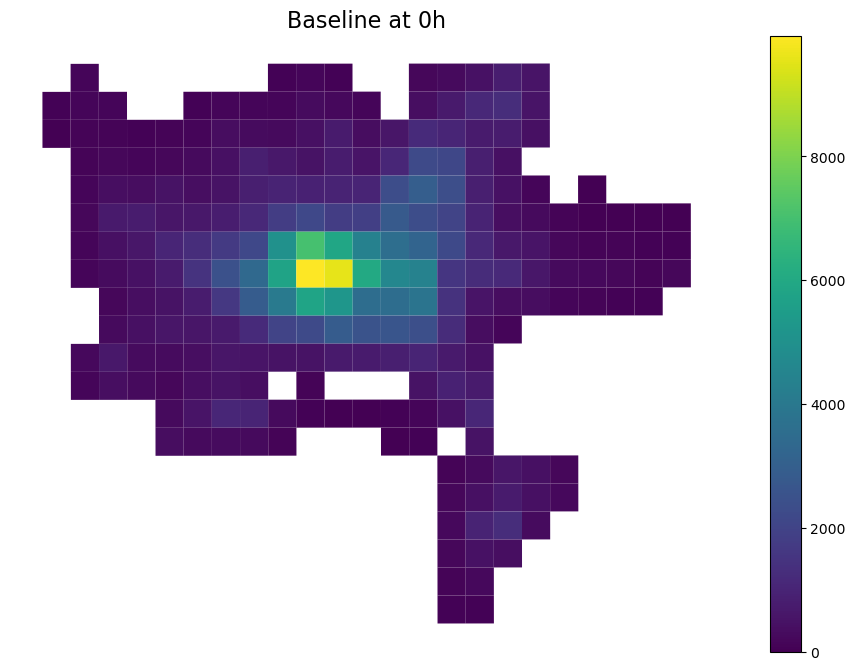

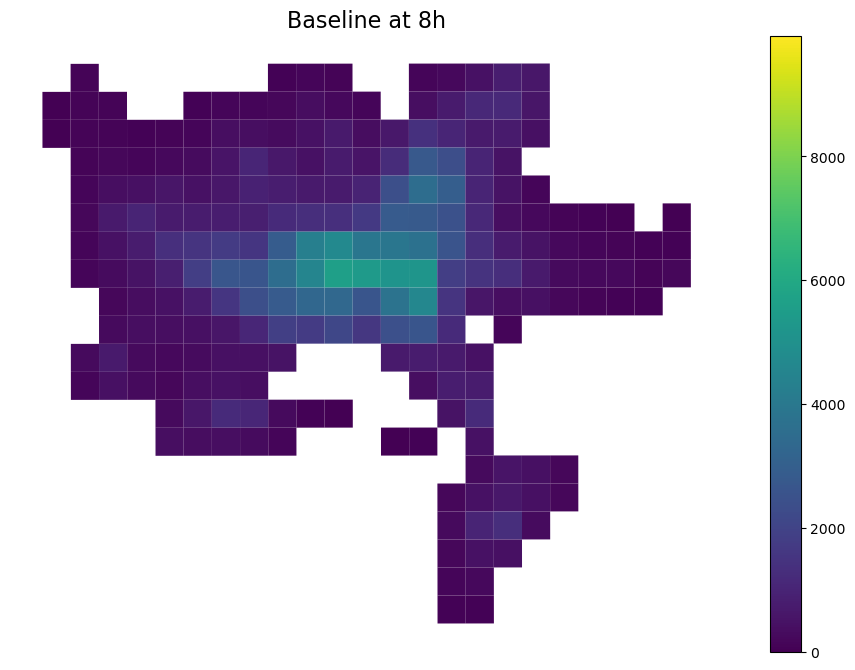

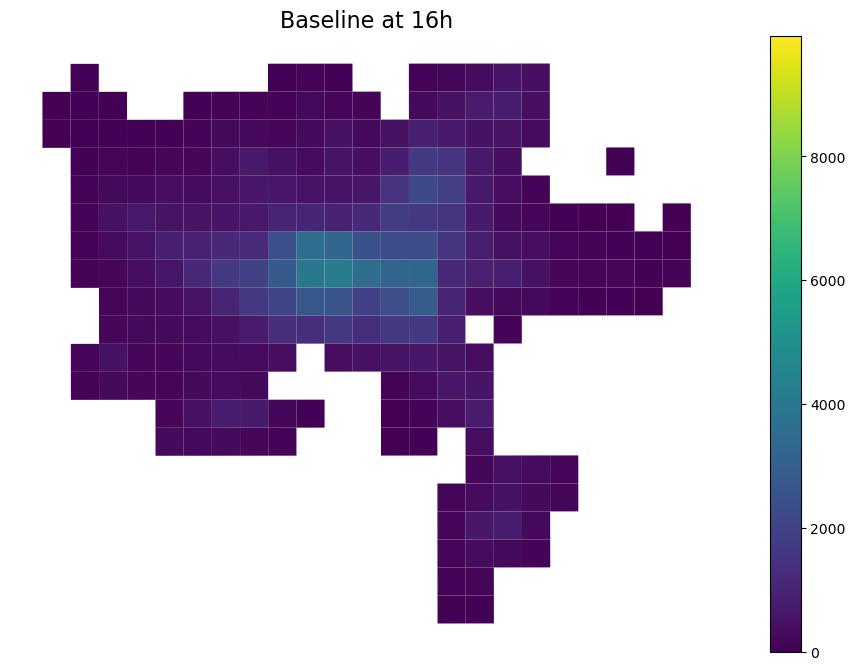

In [16]:
# import matplotlib.pyplot as plt

def plot_baseline(gdf, column='baseline', title='Baseline', cmap='viridis', vmin=None, vmax=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    gdf.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.show()


# Plot each hour
plot_baseline(baseline_0h_gdf, title='Baseline at 0h', vmin=0, vmax=shared_max)
plot_baseline(baseline_8h_gdf, title='Baseline at 8h', vmin=0, vmax=shared_max)
plot_baseline(baseline_16h_gdf, title='Baseline at 16h', vmin=0, vmax=shared_max)

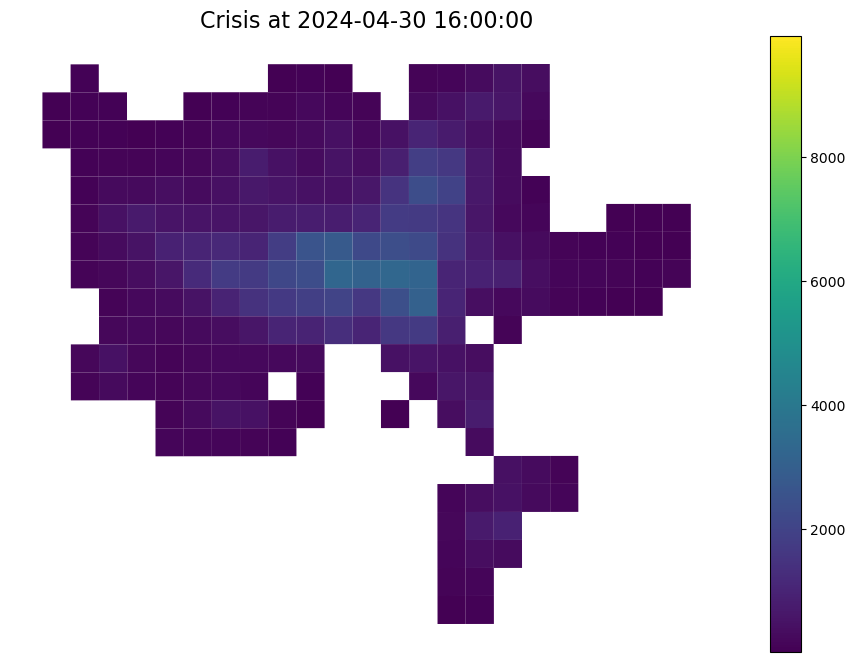

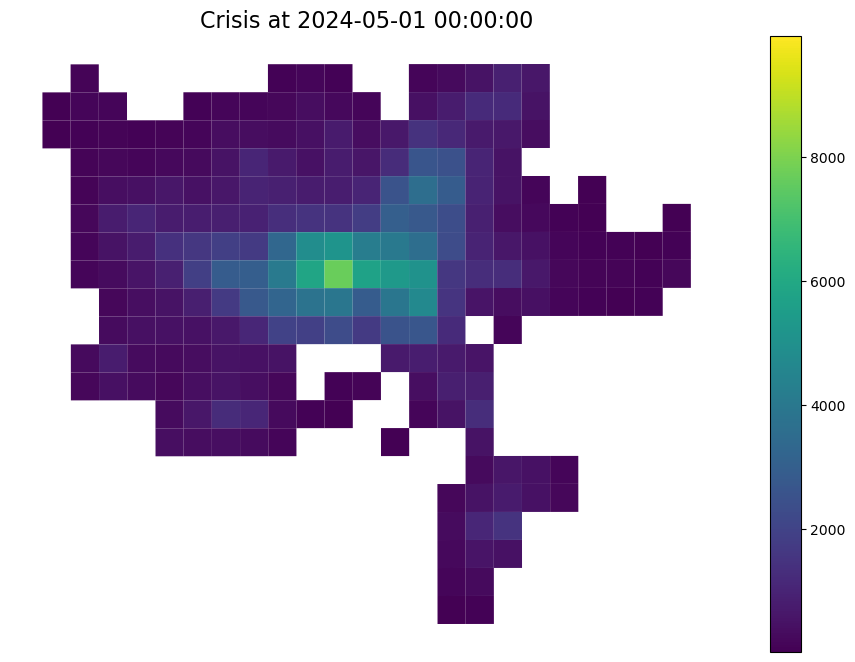

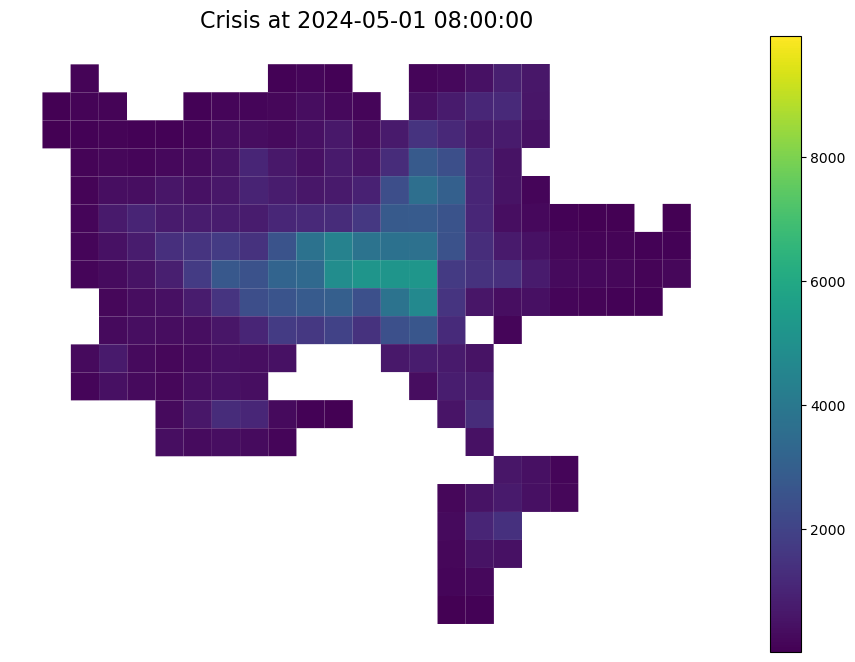

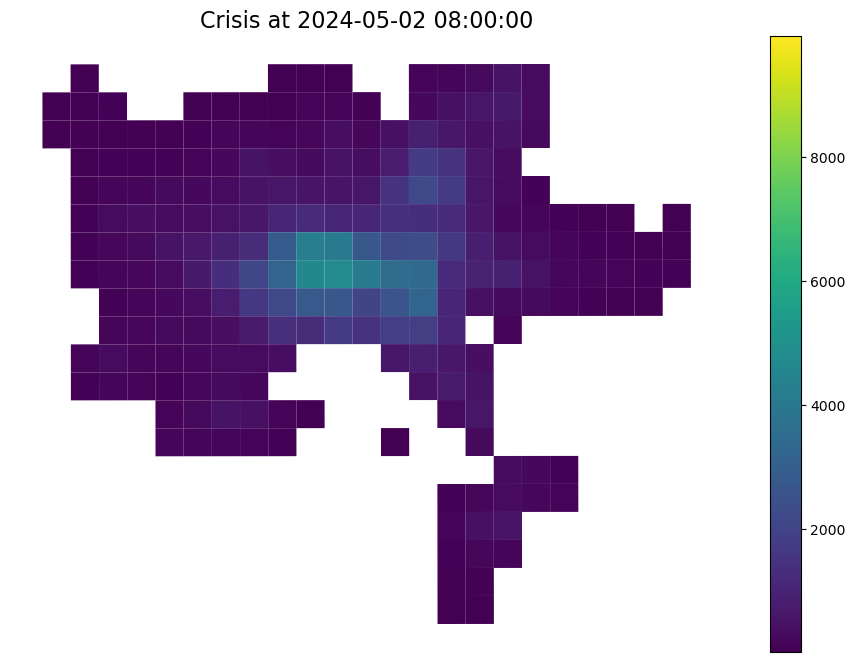

In [40]:
# Extract all crisis columns
crisis_cols = [col for col in fb_wide.columns if col.endswith('_n_crisis')]

# Map column names to timestamps
col_timestamps = {col: pd.to_datetime(col.split('_n_crisis')[0], format='%Y%m%d_%H%M') for col in crisis_cols}

# Select only the columns corresponding to snapshots_to_plot
filtered_cols = [col for col, ts in col_timestamps.items() if ts in snapshots_to_remove]

# Define the plotting function
def plot_crisis(fb_wide, column, title=None, cmap='viridis', vmin=None, vmax=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    fb_wide.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax)
    if title is None:
        title = column
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.show()

# Plot each selected snapshot
for col in filtered_cols:
    plot_crisis(fb_wide, column=col, title=f"Crisis at {col_timestamps[col]}", vmax=shared_max)

## crisis

## Change

Shared ratio color scale: vmin=0.000, vmax=0.266


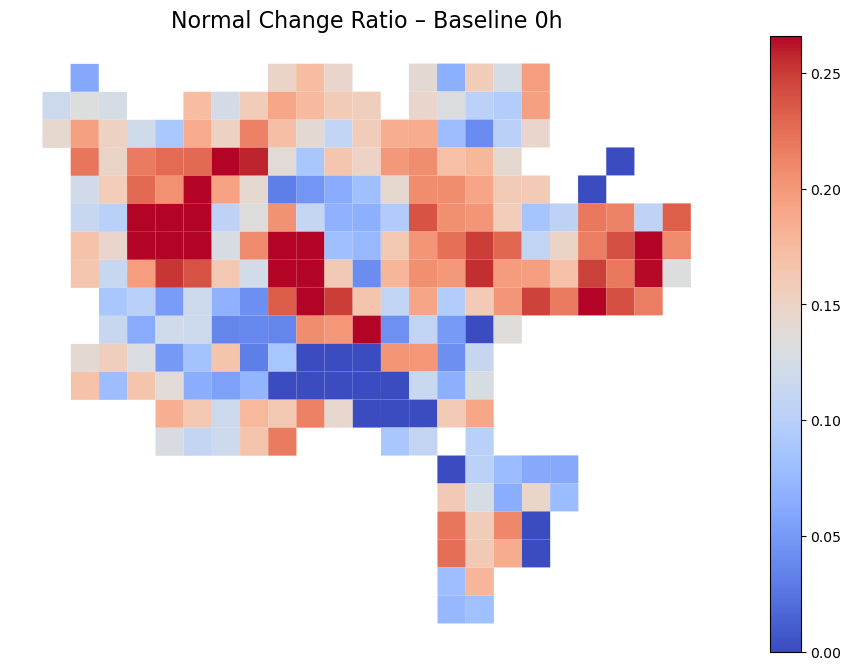

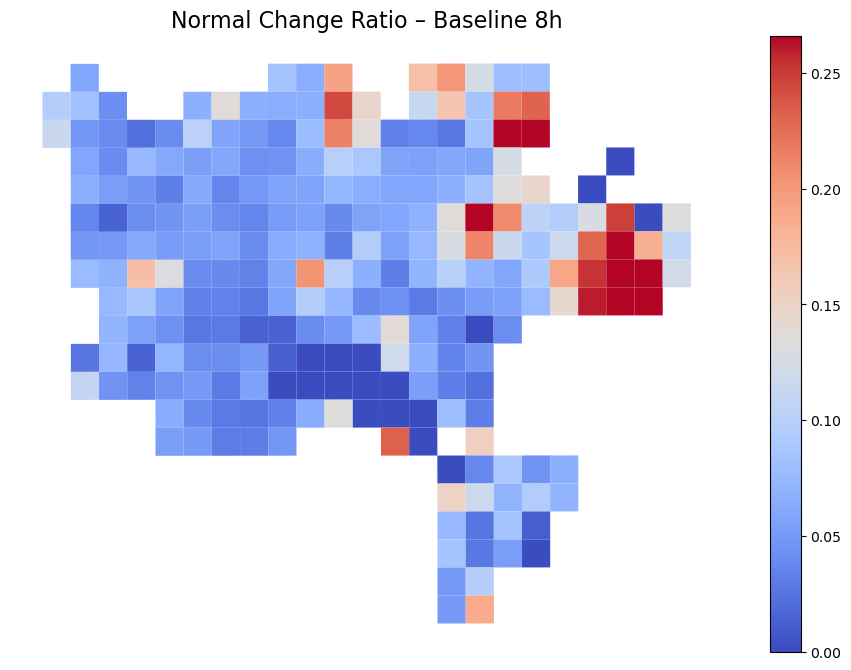

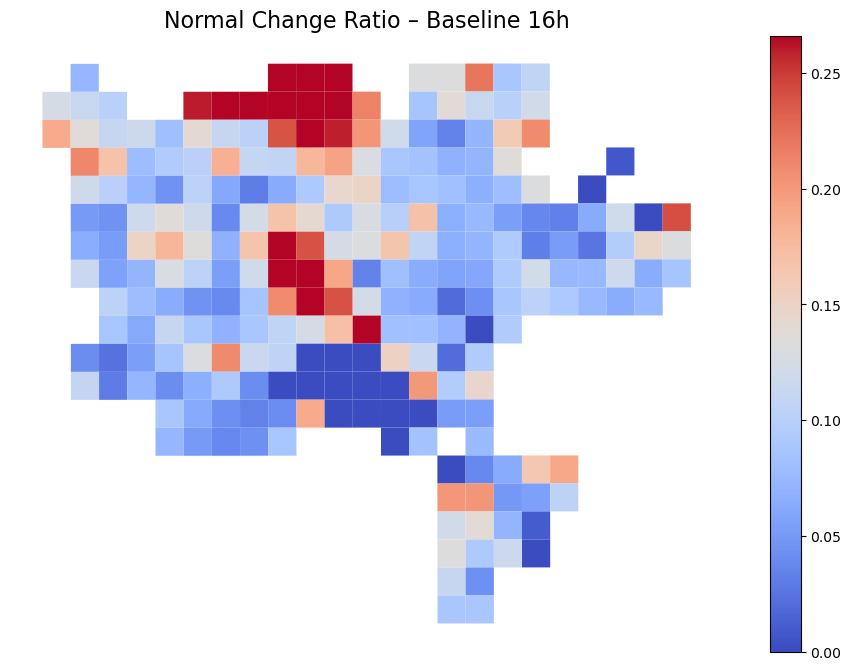

In [19]:
# Define the plotting helper
def plot_map(gdf, column, title=None, cmap='viridis', vmin=None, vmax=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    # gdf.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax, edgecolor='black')
    gdf.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title if title else column, fontsize=16)
    ax.axis('off')
    plt.show()

# Group the GeoDataFrames
datasets = {
    "Baseline 0h": baseline_0h_gdf,
    "Baseline 8h": baseline_8h_gdf,
    "Baseline 16h": baseline_16h_gdf
}

# ---- Shared vmin/vmax setup ----
# Combine all ratio values across all baselines
all_ratios = np.concatenate([gdf['normal_change_ratio'].dropna().values for gdf in datasets.values()])

# Use the 90th percentile for vmax
shared_vmin_ratio = all_ratios.min()
shared_vmax_ratio = np.percentile(all_ratios, 95)

print(f"Shared ratio color scale: vmin={shared_vmin_ratio:.3f}, vmax={shared_vmax_ratio:.3f}")

# ---- Plot each dataset ----
for label, gdf in datasets.items():
    plot_map(
        gdf,
        column='normal_change_ratio',
        title=f"Normal Change Ratio – {label}",
        cmap='coolwarm',
        vmin=shared_vmin_ratio,
        vmax=shared_vmax_ratio
    )


# Export

In [ ]:
baseline_0h_gdf.to_file(OUT_DIR/"baseline_0h_normal_variation.geojson", driver="GeoJSON")
baseline_8h_gdf.to_file(OUT_DIR/"baseline_8h_normal_variation.geojson", driver="GeoJSON")
baseline_16h_gdf.to_file(OUT_DIR/"baseline_16h_normal_variation.geojson", driver="GeoJSON")